In [1]:
# From https://github.com/KrishnaswamyLab/omics_toolbox/blob/main/notebooks/SERGIO-simulation/0.01-SERGIO-simulation.ipynb

# SERGIO Simulation to AnnData + PHATE

Goals:
- Run SERGIO steady-state simulation
- Add realistic technical noise
- Convert to `AnnData` in a preprocess-like structure
- Add `time_bin` for downstream trajectory workflows
- Visualize PHATE and save a `.h5ad` file

## 1. Imports

In [2]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import phate
import matplotlib.pyplot as plt
from pathlib import Path

np.int = int
np.float = float

# Use the root directory of uPHATE repo
import sys
sys.path.append("../")

from SERGIO.SERGIO.sergio import sergio

SERGIO_DATASETS_PATH = Path("../SERGIO/data_sets")

## 2. SERGIO dataset configuration

In [3]:
# === PHATE parameters for bifurcation-style separation ===
phate_knn = 4
phate_decay = 10
phate_t = "auto"

# === Neighbor graph for pseudotime ===
n_neighbors_dpt = 10

# === Pseudotime root and binning ===
root_strategy = "left"  # top, bottom, left, right, or manual
root_index = None  # set integer index when root_strategy="manual"
n_pseudotime_bins = 4
binning = "quantile"  # quantile or uniform

# === SERGIO simulation noise ===
sergio_noise = 0.05
sergio_sampling_state = 15
use_technical_noise = True  # use clean SERGIO state for clearer branch structure

# === Dataset size ===
use_more_genes = False  # Set True to use 200 genes instead of 100

# === techincal noise ==
# outliers
outlier_prob=0.02 # default is 0.01
outlier_mean=0.8 # default is 0.8
outlier_scale=1 # default is 1.

# Add library size effect
library_mean=4.6 
library_scale=0.4

# Add dropouts
dropout_shape=6.5
dropout_percentile=90 # higher = more noise, default is 82

### Tunable Parameters for Clear Trajectory Separation

**Quick tuning guide for clearer branch separation:**

- **For sharper, more separated branches in PHATE:**
  - ↑ `phate_knn` (10-20): smoother manifold
  - ↓ `phate_decay` (10-20): emphasize local structure
  - Set `phate_t` to 50-100: more diffusion → better global structure

- **For less blurry pseudotime bins:**
  - ↓ `n_neighbors_dpt` (10-20): less smoothing, sharper transitions

- **For cleaner trajectory signal:**
  - ↓ `sergio_noise` (0.01-0.05): less noise
  - ↑ `sergio_sampling_state` (20-30): more stable steady state
  - Set `use_more_genes = True`: 200 genes capture more variation

**Recommended starting point for clear separation:**
```python
phate_knn = 15
phate_decay = 10
phate_t = 80
n_neighbors_dpt = 12
sergio_noise = 0.03
sergio_sampling_state = 25
```

Mention the datasets here more clearly

In [4]:
dataset = {
    "DS9": {
        "number_genes": 100,
        "number_bins": 3,
        "number_sc": 300,
        "bifurcation_matrix": "../SERGIO/data_sets/De-noised_100G_3T_300cPerT_dynamics_9_DS4/bMat_cID9.tab",
        "GRN": "../SERGIO/data_sets/De-noised_100G_3T_300cPerT_dynamics_9_DS4/Interaction_cID_9.txt",
        "master_regulator_prod_rate": "../SERGIO/data_sets/De-noised_100G_3T_300cPerT_dynamics_9_DS4/Regs_cID_9.txt",
        "save_location": "../../data/raw/sergio_data/DS9/SERGIO_sim_DS9.npy"
    },
    "DS10": {
        "number_genes": 100,
        "number_bins": 4,
        "number_sc": 300,
        "bifurcation_matrix": "../SERGIO/data_sets/De-noised_100G_4T_300cPerT_dynamics_10_DS5/bMat_cID10.tab",
        "GRN": "../SERGIO/data_sets/De-noised_100G_4T_300cPerT_dynamics_10_DS5/Interaction_cID_10.txt",
        "master_regulator_prod_rate": "../SERGIO/data_sets/De-noised_100G_4T_300cPerT_dynamics_10_DS5/Regs_cID_10.txt",
        "save_location": "../SERGIO/data_sets/De-noised_100G_4T_300cPerT_dynamics_10_DS5/SERGIO_sim_DS10.npy"
    },
    "DS12": {
        "number_genes": 100,
        "number_bins": 7,
        "number_sc": 300,
        "bifurcation_matrix": "../../data/raw/sergio_data/DS12/bMat_cID12.tab",
        "GRN": "../../data/raw/sergio_data/DS12/Interaction_cID_12.txt",
        "master_regulator_prod_rate": "../../data/raw/sergio_data/DS12/Regs_cID_12.txt",
        "save_location": "../../data/raw/sergio_data/DS12/SERGIO_sim_DS12.npy"
    }
}

# For a clean bifurcation benchmark-like shape, start with DS9
sim_id = "DS10"  # choose from: DS9, DS10, DS12

# Apply gene count override if requested
if use_more_genes:
    dataset[sim_id]["number_genes"] = 200
    
dataset[sim_id]

{'number_genes': 100,
 'number_bins': 4,
 'number_sc': 300,
 'bifurcation_matrix': '../SERGIO/data_sets/De-noised_100G_4T_300cPerT_dynamics_10_DS5/bMat_cID10.tab',
 'GRN': '../SERGIO/data_sets/De-noised_100G_4T_300cPerT_dynamics_10_DS5/Interaction_cID_10.txt',
 'master_regulator_prod_rate': '../SERGIO/data_sets/De-noised_100G_4T_300cPerT_dynamics_10_DS5/Regs_cID_10.txt',
 'save_location': '../SERGIO/data_sets/De-noised_100G_4T_300cPerT_dynamics_10_DS5/SERGIO_sim_DS10.npy'}

## 3. Run steady-state SERGIO simulation

In [5]:
sim = sergio(
    number_genes=dataset[sim_id]["number_genes"],
    number_bins=dataset[sim_id]["number_bins"],
    number_sc=dataset[sim_id]["number_sc"],
    noise_params=sergio_noise,
    decays=0.8,
    sampling_state=sergio_sampling_state,
    noise_type='dpd'
)

sim.build_graph(
    dataset[sim_id]["GRN"],
    input_file_regs=dataset[sim_id]["master_regulator_prod_rate"],
    shared_coop_state=2
)

sim.simulate()
expr = sim.getExpressions()
expr_clean = np.concatenate(expr, axis=1)

print(f"Clean expression matrix shape (genes x cells): {expr_clean.shape}")

Start simulating new level
There are 3 genes to simulate in this layer
Done with current level
Start simulating new level
There are 7 genes to simulate in this layer
Done with current level
Start simulating new level
There are 90 genes to simulate in this layer
Done with current level
Clean expression matrix shape (genes x cells): (100, 1200)


## 4. Add technical noise and generate count matrix

In [6]:
# Add outlier genes
expr_o = sim.outlier_effect(expr, outlier_prob=outlier_prob, mean=outlier_mean, scale=outlier_scale)

# Add library size effect
lib_factor, expr_o_l = sim.lib_size_effect(expr_o, mean=library_mean, scale=library_scale)

# Add dropouts
binary_ind = sim.dropout_indicator(expr_o_l, shape=dropout_shape, percentile=dropout_percentile)
expr_o_l_d = np.multiply(binary_ind, expr_o_l)

# Convert to UMI counts
count_matrix = sim.convert_to_UMIcounts(expr_o_l_d)
count_matrix = np.concatenate(count_matrix, axis=1)
print("Using technical-noise count matrix")


# Guardrail: if cells are nearly identical, add tiny jitter so PHATE does not collapse
unique_cells = np.unique(count_matrix.T, axis=0).shape[0]
if unique_cells <= count_matrix.shape[1]:
    rng = np.random.default_rng(0)
    count_matrix = count_matrix + rng.normal(loc=0.0, scale=1e-3, size=count_matrix.shape)
    count_matrix = np.clip(count_matrix, a_min=0, a_max=None)
    unique_cells = np.unique(count_matrix.T, axis=0).shape[0]
    print("Applied tiny jitter to break exact duplicates between cells")

print(f"Expression matrix used for AnnData (genes x cells): {count_matrix.shape}")
print(f"Unique cell profiles before PHATE: {unique_cells}")

Using technical-noise count matrix
Applied tiny jitter to break exact duplicates between cells
Expression matrix used for AnnData (genes x cells): (100, 1200)
Unique cell profiles before PHATE: 1200


## 5. Convert to AnnData and keep simulation time labels

In [7]:
# SERGIO output is genes x cells; AnnData expects cells x genes
X_cells_by_genes = count_matrix.T
X_clean = expr_clean.T
adata = sc.AnnData(X=X_cells_by_genes)
adata.obsm["X_clean"] = X_clean

adata.var_names = [f"G{i}" for i in range(adata.n_vars)]
adata.obs_names = [f"cell_{i}" for i in range(adata.n_obs)]

# Keep simulation bins as reference labels
cells_per_bin = dataset[sim_id]["number_sc"]
number_bins = dataset[sim_id]["number_bins"]
expected_n_obs = cells_per_bin * number_bins

if adata.n_obs != expected_n_obs:
    raise ValueError(
        f"Expected {expected_n_obs} cells ({number_bins} bins x {cells_per_bin} cells), got {adata.n_obs}."
    )

adata.obs["sim_time_bin"] = np.repeat(np.arange(number_bins, dtype=float), cells_per_bin)
adata.obs["sim_timepoint"] = adata.obs["sim_time_bin"].map(lambda x: f"Bin {int(x)}")

adata

AnnData object with n_obs × n_vars = 1200 × 100
    obs: 'sim_time_bin', 'sim_timepoint'
    obsm: 'X_clean'

## 6. PHATE embedding + pseudotime (8 bins)

In [8]:
# Preprocess and compute PCA directly on adata
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.pca(adata, n_comps=min(30, adata.n_vars - 1))

# Compute PHATE on PCA embedding and store
phate_operator = phate.PHATE(
    n_components=2,
    knn=phate_knn,
    decay=phate_decay,
    t=phate_t,
    random_state=1,
    n_landmark=None,
    mds_solver="smacof",
)
adata.obsm["X_phate"] = phate_operator.fit_transform(adata.obsm["X_pca"])

# Compute pseudotime using diffusion pseudotime (DPT)
sc.pp.neighbors(adata, n_neighbors=n_neighbors_dpt, n_pcs=min(30, adata.n_vars - 1))
sc.tl.diffmap(adata)

# Choose root to orient trajectory
if root_strategy == "manual" and root_index is not None:
    root_idx = int(root_index)
elif root_strategy == "top":
    root_idx = int(np.argmax(adata.obsm["X_phate"][:, 1]))
elif root_strategy == "bottom":
    root_idx = int(np.argmin(adata.obsm["X_phate"][:, 1]))
elif root_strategy == "left":
    root_idx = int(np.argmin(adata.obsm["X_phate"][:, 0]))
elif root_strategy == "right":
    root_idx = int(np.argmax(adata.obsm["X_phate"][:, 0]))
else:
    root_idx = int(np.argmin(adata.obsm["X_phate"][:, 0]))

adata.uns["iroot"] = root_idx
sc.tl.dpt(adata)

# Store pseudotime bins
if binning == "uniform":
    adata.obs["pseudotime_bin"] = pd.cut(
        adata.obs["dpt_pseudotime"],
        bins=n_pseudotime_bins,
        labels=False,
        include_lowest=True
    ).astype(int)
else:
    adata.obs["pseudotime_bin"] = pd.qcut(
        adata.obs["dpt_pseudotime"],
        q=n_pseudotime_bins,
        labels=False,
        duplicates="drop"
    ).astype(int)

Calculating PHATE...
  Running PHATE on 1200 observations and 30 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 0.06 seconds.
    Calculating affinities...
    Calculated affinities in 1.10 seconds.
  Calculated graph and diffusion operator in 1.19 seconds.
  Calculating optimal t...
    Automatically selected t = 18
  Calculated optimal t in 1.24 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.40 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 1.31 seconds.
Calculated PHATE in 4.23 seconds.


/Users/tlong/Documents/code/uPHATE/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


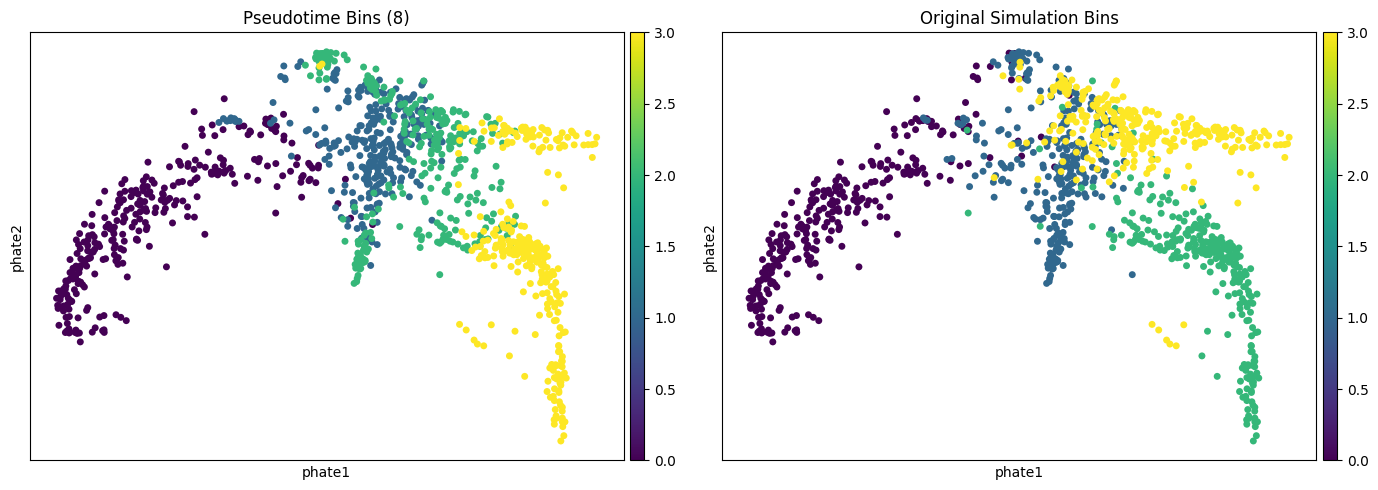


Parameters used:
  PHATE: knn=4, decay=10, t=auto
  DPT neighbors: 10
  SERGIO noise: 0.05
  Sampling state: 15


In [9]:
# Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pseudotime bins
sc.pl.embedding(
    adata,
    basis='phate',
    color='pseudotime_bin',
    cmap='viridis',
    ax=axes[0],
    title='Pseudotime Bins (8)',
    show=False
)

# Simulation bins (reference)
sc.pl.embedding(
    adata,
    basis='phate',
    color='sim_time_bin',
    cmap='viridis',
    ax=axes[1],
    title='Original Simulation Bins',
    show=False
)

plt.tight_layout()
plt.show()

print(f"\nParameters used:")
print(f"  PHATE: knn={phate_knn}, decay={phate_decay}, t={phate_t}")
print(f"  DPT neighbors: {n_neighbors_dpt}")
print(f"  SERGIO noise: {sergio_noise}")
print(f"  Sampling state: {sergio_sampling_state}")

## Bootstrapped Embeddings

In [11]:
from uphate.numpy_interface import BootstrappedPHATE

def extract_phate_posterior_stats(posterior_embeddings):
    """
    posterior_embeddings: numpy array of shape (n_samples, n_cells, 2)
    """
    # Calculate the mean embedding across the posterior samples
    mean_phate_embedding = np.mean(posterior_embeddings, axis=0)
    
    # Calculate the local uncertainty (trace of the covariance matrix of the 2D spatial variance per cell)
    # This yields a single uncertainty value per cell
    variances = np.var(posterior_embeddings, axis=0) # Shape: (n_cells, 2)
    local_uncertainty = np.sum(variances, axis=1)    # Sum of variance in X and Y
    
    return mean_phate_embedding, local_uncertainty

In [12]:
phate_op = BootstrappedPHATE(
    n_boostrap_samples=10,
    dirichlet_alpha=0.5,
    knn=phate_knn,
    decay=phate_decay,
    t=phate_t,
    n_landmark=None,
    mds_solver="smacof",
)
base_phate, posterior_embeddings = phate_op.fit_transform(adata.obsm["X_pca"])
mean_phate_embedding, local_uncertainty = extract_phate_posterior_stats(posterior_embeddings)
adata.obsm["X_bootstrap"] = mean_phate_embedding
adata.obs["bootstrap_variance"] = local_uncertainty
adata.obs["bootstrap_std"] = np.sqrt(local_uncertainty)

Calculating PHATE...
  Running PHATE on 1200 observations and 30 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 0.03 seconds.
    Calculating affinities...
    Calculated affinities in 0.03 seconds.
  Calculated graph and diffusion operator in 0.06 seconds.
  Calculating Baseline embedding...
    Calculating optimal t...
      Automatically selected t = 18
    Calculated optimal t in 0.84 seconds.
    Calculating diffusion potential...
    Calculated diffusion potential in 0.44 seconds.
    Calculating metric MDS...
    Calculated metric MDS in 1.38 seconds.
  Calculated Baseline embedding in 2.69 seconds.
  Calculating Bootstrap embedding 0...
    Calculating optimal t...
      Automatically selected t = 22
    Calculated optimal t in 1.26 seconds.
    Calculating diffusion potential...
    Calculated diffusion potential in 0.52 seconds.
    Calculating metric MDS...
    Calculated metric MDS in 1.06 seconds.
  Calcu

## Visualize bootstrap

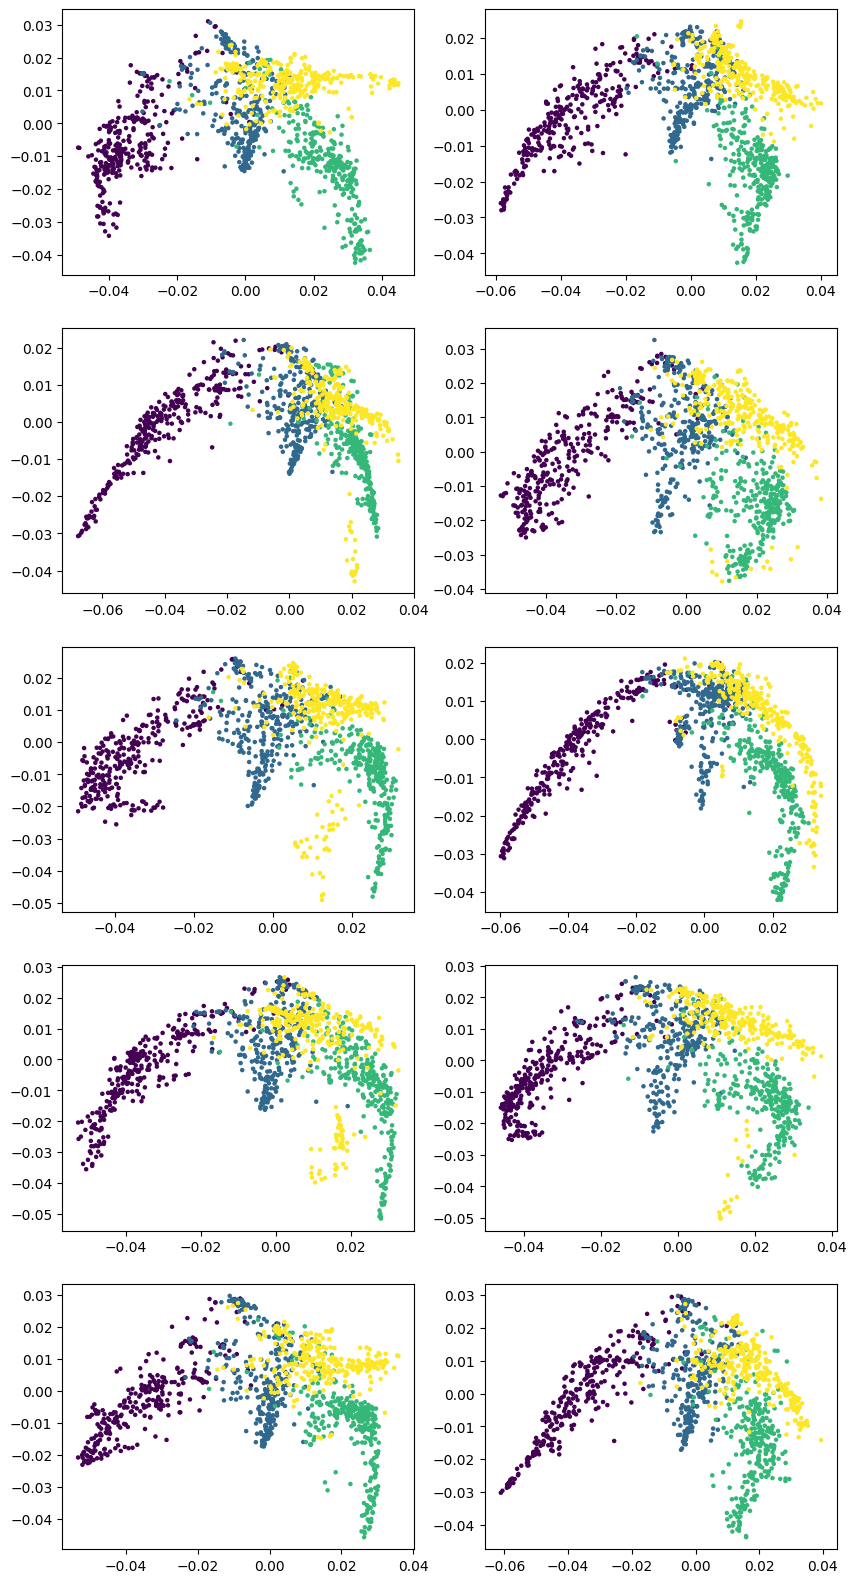

In [32]:
fig, axs = plt.subplots(5, 2, figsize=(10, 20))

dists_to_root = np.zeros((posterior_embeddings.shape[0], posterior_embeddings.shape[1]))

for i, (embedding, ax) in enumerate(zip(posterior_embeddings, axs.flat)):
    if root_strategy == "manual" and root_index is not None:
        root_idx = int(root_index)
    elif root_strategy == "top":
        root_idx = int(np.argmax(adata.obsm["X_phate"][:, 1]))
    elif root_strategy == "bottom":
        root_idx = int(np.argmin(adata.obsm["X_phate"][:, 1]))
    elif root_strategy == "left":
        root_idx = int(np.argmin(adata.obsm["X_phate"][:, 0]))
    elif root_strategy == "right":
        root_idx = int(np.argmax(adata.obsm["X_phate"][:, 0]))
    else:
        root_idx = int(np.argmin(adata.obsm["X_phate"][:, 0]))

    root = embedding[root_idx]
    dist_to_root = np.linalg.norm(embedding - root, axis=1)
    dist_to_root /= dist_to_root.max()
    dists_to_root[i] = dist_to_root

    ax.scatter(*embedding.T, c=adata.obs["sim_time_bin"], s=5)

adata.obs["dist_to_root_mean"] = dists_to_root.mean(axis=0)
adata.obs["dist_to_root_std"] = dists_to_root.std(axis=0)

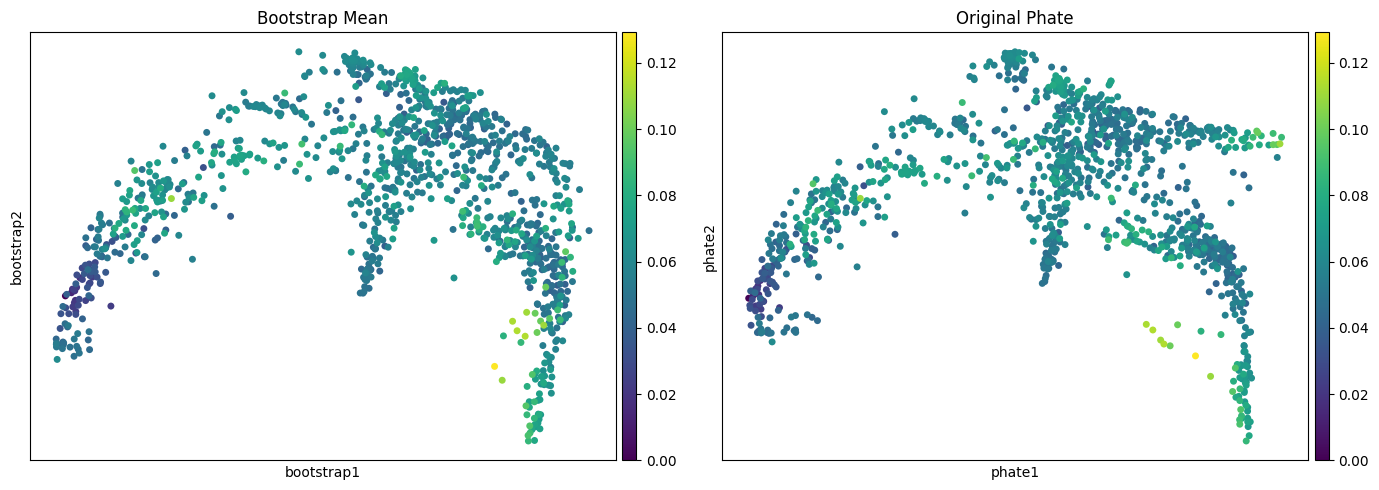

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc.pl.embedding(
    adata,
    basis='bootstrap',
    color='dist_to_root_std',
    cmap='viridis',
    title='Bootstrap Mean',
    show=False,
    ax=axes[0]
)

sc.pl.embedding(
    adata,
    basis='phate',
    color='dist_to_root_std',
    cmap='viridis',
    title='Original Phate',
    show=False,
    ax=axes[1]
)
fig.tight_layout()

## Evaluation

In [29]:
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr, rankdata
import networkx as nx

def evaluate_embedding(clean_data, mean_embedding, true_pseudotime, local_uncertainty):
    results = {}
    
    # ---------------------------------------------------------
    # 1. DEMaP Score (Global Manifold Preservation)
    # ---------------------------------------------------------
    # Calculate pairwise distances of the true uncorrupted manifold
    clean_distances = pdist(clean_data, metric='euclidean') 
    
    # Calculate pairwise distances in the mean PHATE embedding
    phate_distances = pdist(mean_embedding, metric='euclidean')
    
    # DEMaP is the Spearman correlation between clean high-dim and embedded low-dim distances
    demap_score, _ = spearmanr(clean_distances, phate_distances)
    results["demap"] = demap_score
    
    # ---------------------------------------------------------
    # 2. Pseudotime Rank Correlation (Temporal Accuracy)
    # ---------------------------------------------------------
    # Identify the root cell (index 0) and calculate distance to all other cells in 2D space
    root_cell = mean_embedding[root_idx]
    inferred_distances = np.linalg.norm(mean_embedding - root_cell, axis=1)
    
    # Rank both the true time and inferred distances
    true_ranks = rankdata(true_pseudotime)
    inferred_ranks = rankdata(inferred_distances)
    
    temporal_rho, _ = spearmanr(true_ranks, inferred_ranks)
    results["temporal_rho"] = temporal_rho
    
    # ---------------------------------------------------------
    # 3. Uncertainty Alignment (Local Error vs Local Uncertainty)
    # ---------------------------------------------------------
    # Define local error as the absolute deviation in pseudotime ranking per cell
    local_error = np.abs(true_ranks - inferred_ranks)
    
    # Evaluate if higher uncertainty strongly correlates with higher local error
    alignment_score, alignment_pval = spearmanr(local_error, local_uncertainty)
    results["alignment"] = alignment_score
    
    return results, local_error


In [30]:
metrics, local_error = evaluate_embedding(
    adata.obsm["X_clean"],
    adata.obsm["X_bootstrap"],
    adata.obs["sim_time_bin"],
    adata.obs["dist_to_root_std"],
)
print(metrics)

{'demap': 0.5384017175417918, 'temporal_rho': 0.8080014311586237, 'alignment': -0.07758176860551935}


## Visualization

/var/folders/rn/jqrwv4s94353h34h4r7t__sm0000gn/T/ipykernel_18252/3258614193.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


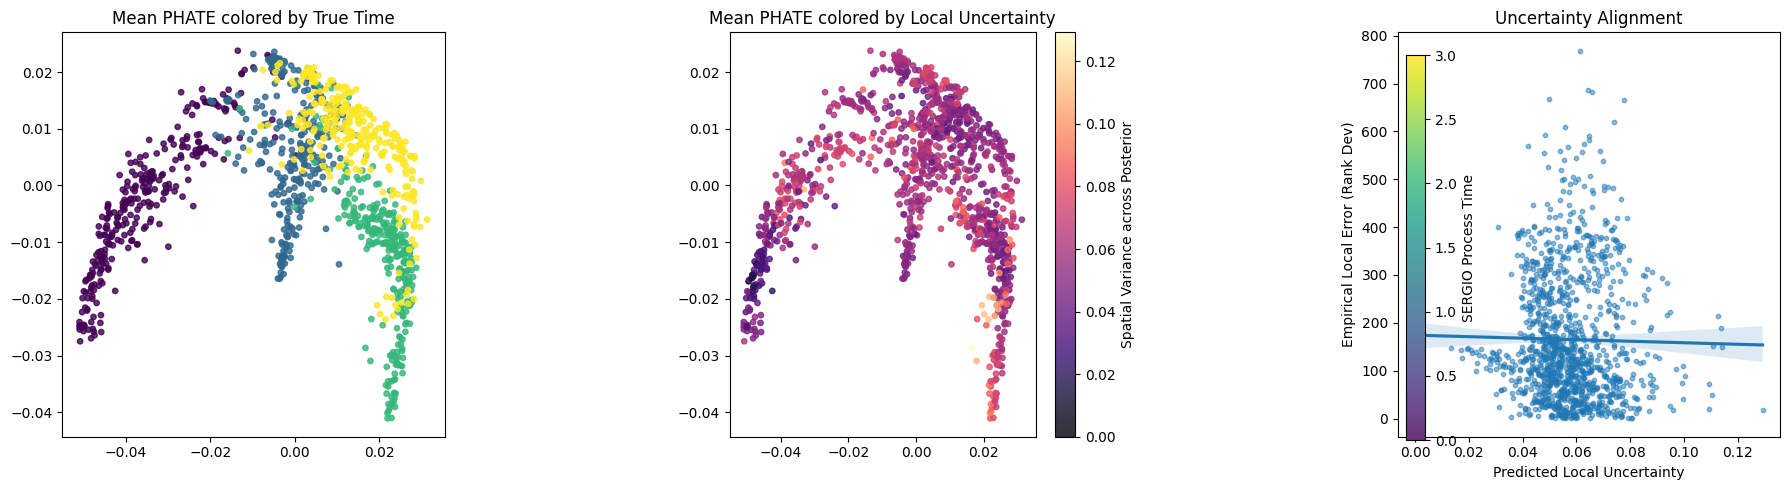

In [31]:
import seaborn as sns


def visualize_results(mean_embedding, true_pseudotime, local_uncertainty, local_error):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Plot 1: Mean PHATE colored by Ground Truth Process Time
    scatter1 = axes[0].scatter(
        mean_embedding[:, 0],
        mean_embedding[:, 1],
        c=true_pseudotime,
        cmap="viridis",
        s=15,
        alpha=0.8,
    )
    axes[0].set_title("Mean PHATE colored by True Time")
    fig.colorbar(scatter1, ax=axes, label="SERGIO Process Time")

    # Plot 2: Mean PHATE colored by Posterior Uncertainty
    scatter2 = axes[1].scatter(
        mean_embedding[:, 0],
        mean_embedding[:, 1],
        c=local_uncertainty,
        cmap="magma",
        s=15,
        alpha=0.8,
    )
    axes[1].set_title("Mean PHATE colored by Local Uncertainty")
    fig.colorbar(scatter2, ax=axes[1], label="Spatial Variance across Posterior")

    # Plot 3: Uncertainty Calibration (Local Error vs Local Uncertainty)
    sns.regplot(
        x=local_uncertainty,
        y=local_error,
        ax=axes[2],
        scatter_kws={"alpha": 0.5, "s": 10},
    )
    axes[2].set_title("Uncertainty Alignment")
    axes[2].set_xlabel("Predicted Local Uncertainty")
    axes[2].set_ylabel("Empirical Local Error (Rank Dev)")

    plt.tight_layout()
    plt.show()


visualize_results(
    adata.obsm["X_bootstrap"], adata.obs["sim_time_bin"], adata.obs["dist_to_root_std"], local_error
)